# Import Libraries

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import pandas as pd
import seaborn as sns
import joblib
import json
import matplotlib.pyplot as plt

# Loading Data

In [ ]:
!pip install catboost

In [29]:
rf_model = joblib.load("/content/drive/MyDrive/Music_Recom_ML/Models/Random_Forest_Tuned.pkl")
lgbm_model = joblib.load("/content/drive/MyDrive/Music_Recom_ML/Models/LightGBM_Tuned.pkl")
xgb_model = joblib.load("/content/drive/MyDrive/Music_Recom_ML/Models/XGBoost_Tuned.pkl")
cat_model = joblib.load("/content/drive/MyDrive/Music_Recom_ML/Models/CatBoost_Tuned.pkl")
dt_model = joblib.load("/content/drive/MyDrive/Music_Recom_ML/Models/Decision_Tree_Tuned.pkl")
ada_model = joblib.load("/content/drive/MyDrive/Music_Recom_ML/Models/AdaBoost_Tuned.pkl")

In [31]:
X_val = pd.read_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/X_val.parquet")
y_val = pd.read_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/y_val.parquet")

In [10]:
with open("/content/drive/MyDrive/Music_Recom_ML/Processed/features.json", 'r') as file:
    data = json.load(file)

In [6]:
RESULTS_FILE = "/content/drive/MyDrive/Music_Recom_ML/Results/Model_results.csv"
results_df = pd.read_csv(RESULTS_FILE)

# Evaluation Function

In [35]:
def evaluate_model(y_true, pred_probs):

  pred_labels = (pred_probs > 0.5).astype(int)

  accuracy = accuracy_score(y_true, pred_labels)
  precision = precision_score(y_true, pred_labels)
  recall = recall_score(y_true, pred_labels)
  f1 = f1_score(y_true, pred_labels)
  auc = roc_auc_score(y_true, pred_probs)

  return accuracy, precision, recall, f1, auc, pred_labels

# Feature Importance Analysis

In [30]:
combined = pd.DataFrame({
    "Feature": data,
    "RandomForest": rf_model.feature_importances_,
    "XGBoost": xgb_model.feature_importances_,
    "LightGBM": lgbm_model.feature_importances_,
    "CatBoost": cat_model.feature_importances_,
    "DecisionTree": dt_model.feature_importances_,
    "AdaBoost": ada_model.feature_importances_
})

for col in combined.columns[1:]:
    combined[col] = combined[col] / combined[col].sum()

combined["AverageImportance"] = combined.iloc[:,1:].mean(axis=1)

combined = combined.sort_values("AverageImportance", ascending=False)

combined.head(20)

,Feature,RandomForest,XGBoost,LightGBM,CatBoost,DecisionTree,AdaBoost,AverageImportance
2,source_type,0.232461,0.214455,0.043284,0.175458,0.539907,0.198419,0.233997
27,song_play_count,0.112763,0.080096,0.046615,0.049672,0.112150,0.208294,0.101598
29,song_user_count,0.122002,0.132727,0.000000,0.052002,0.186001,0.089064,0.096966
1,source_screen_name,0.192261,0.086292,0.039325,0.069880,0.010010,0.165418,0.093864
26,user_song_count,0.023479,0.033154,0.127409,0.062228,0.036680,0.087499,0.061742
0,source_system_tab,0.169870,0.034647,0.027295,0.046433,0.020630,0.060240,0.059853
30,user_unique_artists,0.017406,0.029849,0.122050,0.097891,0.025154,0.000000,0.048725
28,user_unique_songs,0.025456,0.033874,0.000000,0.066023,0.045169,0.082355,0.042146
16,membership_days,0.015273,0.021552,0.086993,0.037140,0.006148,0.014901,0.030334
17,account_age_days,0.004680,0.021077,0.068484,0.048375,0.002883,0.009441,0.025823


# Weighted Boosting Ensemble

In [33]:
cat_probs = cat_model.predict_proba(X_val)[:,1]
lgb_probs = lgbm_model.predict_proba(X_val)[:,1]
xgb_probs = xgb_model.predict_proba(X_val)[:,1]

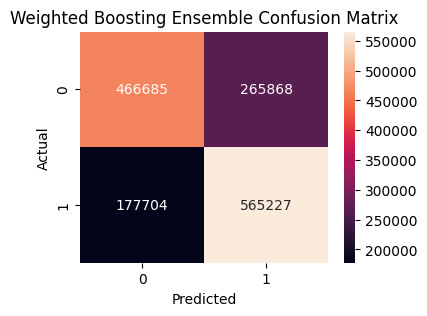

In [52]:
ensemble_probs = (0.2 * cat_probs + 0.5 * lgb_probs + 0.3 * xgb_probs)
accuracy, precision, recall, f1, auc, pred_labels = evaluate_model(y_val, ensemble_probs)

name = "Weighted Boosting Ensemble"

cf = confusion_matrix(y_val, pred_labels)
plt.figure(figsize=(4,3))
sns.heatmap(cf, annot=True, fmt='d')
plt.title(f"{name} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

result = {"Model": name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1, "AUC": auc}
results_df = pd.concat([results_df, pd.DataFrame([result])], ignore_index=True)

# Final Comparison

In [53]:
results_df = results_df[["Model", "AUC","Accuracy", "Precision", "Recall", "F1"]]

results_df.sort_values(by=["AUC", "Accuracy"],ascending=False).style.background_gradient(cmap='rocket')

,Model,AUC,Accuracy,Precision,Recall,F1
11,LightGBM Tuned,0.785452,0.710959,0.704941,0.732586,0.718498
21,Weighted Boosting Ensemble,0.774654,0.699372,0.680099,0.760807,0.718193
16,XGBoost Tuned,0.762197,0.692048,0.681635,0.728785,0.704422
14,CatBoost Tuned,0.745669,0.660392,0.618001,0.852434,0.716530
13,CatBoost (1000 iters),0.738048,0.674943,0.664854,0.714699,0.688876
15,XGBoost Base,0.733069,0.671965,0.661374,0.714170,0.686759
10,LightGBM Base,0.731699,0.670623,0.660783,0.710676,0.684822
12,CatBoost (300 iters),0.718115,0.661620,0.650548,0.708604,0.678336
4,Random Forest Tuned,0.703703,0.653048,0.642674,0.700318,0.670259
1,Decision Tree Tuned,0.700111,0.652721,0.643678,0.695058,0.668382


In [65]:
results_df.to_csv(RESULTS_FILE, index=False)